
______________________________________________________________________

I. Теориялық тапсырмалар

> ## 1-тапсырма Метрикаларды түсіндіру


Берілген мәндер: TP=45, FP=15, FN=5, TN=435.
Accuracy (Дәлдік):  
Total=45+435/500=0.96 (96%)

Precision (Дәлдік/Талғампаздық):  
45/45+15=0.75

Recall (Толықтық):  

45/45+5=0.90

F1-score: 2⋅Precision⋅Recall/Precision+Recall= 2⋅0.75⋅0.90 / 0.75+0.90 ≈ 0.818

> Қай метрика маңызды? Бұл жағдайда Recall маңыздырақ болуы мүмкін, себебі біз нақты оң жағдайларды (мысалы, ауруды) жіберіп алмауымыз керек (FN=5 өте аз болғаны жақсы)
______________________________________________________________________



## 2-тапсырма Accuracy неге жеткіліксіз?
Accuracy неге тең? 10,000 үлгінің 9,800-і negative. Егер модель бәрін negative десе, Accuracy = 9800 / 10000=98%


> Жақсы модель ме? Жоқ, Модель бірде-бір positive (200 дана) нысанды таба алмады. Ол жұмыс істемейді

> Қандай метрикалар? Precision, Recall, F1-score және ROC-AUC қолдану керек

______________________________________________________________________
> 3-тапсырма

Кросс-валидация теориясы

> K-fold cross-validation деген не? Бұл модельдің тиімділігін бағалау әдісі. Деректер жиыны K тең бөлікке (fold) бөлінеді. Модель K рет оқытылады: әр жолы бір бөлік тест үшін, ал қалған K−1 бөлік оқыту үшін қолданылады. Соңында барлық нәтижелердің орташа мәні алынады.

> Leave-One-Out CV (LOOCV) қашан тиімсіз? Бұл әдіс деректер жиыны өте үлкен болғанда тиімсіз. Себебі LOOCV әр нысанды жеке-жеке тест ретінде қарастырады (егер N нысан болса, модель N рет оқытылады), бұл өте көп уақыт пен есептеу қуатын талап етеді

> Stratified K-Fold не үшін қажет? Бұл әдіс теңгерімсіз (imbalanced) деректер жиынында кластардың пропорциясын сақтау үшін қажет. Мысалы, егер деректердің 90%-ы "0" және 10%-ы "1" болса, Stratified әдісі әрбір бөлікте (fold) осы 90/10 қатынасының сақталуын қадағалайды

> Overfitting-ті CV қалай анықтайды? Егер модель оқыту деректерінде (train score) өте жоғары нәтиже көрсетіп, ал кросс-валидация кезінде (validation score) нәтижесі айтарлықтай төмен болса, бұл модельдің оверфиттингке (қайта оқытылуға) ұшырағанын білдіреді


______________________________________________________________________


>  4-тапсырма. Гиперпараметрлерді жіктеу

Learning rate: Гиперпараметр

Model weights: Параметр

Number of trees: Гиперпараметр

Regularization coefficient: Гиперпараметр

Bias: Параметр

______________________________________________________________________


> 5-тапсырма. SMOTE теориясы
Негізгі идеясы: Аз кластағы нысандардың көшірмесін жасау емес, олардың арасынан жаңа, жасанды (синтетикалық) нүктелер құрастыру.
Формуласы: 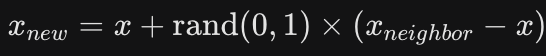


Қаупі: Егер деректерде "шу" көп болса немесе кластар бір-бірімен қатты араласып кетсе, SMOTE қате нысандар жасап, модельді шатастыруы мүмкін.

Қолдану: SMOTE-ты тек train (оқыту) бөлігіне қолдану керек; тест жиынына қолдануға болмайды.

______________________________________________________________________


> 6-тапсырма. Class weight


Не өзгереді: Модель аз кластың қателерін маңыздырақ деп санап, оларға көбірек басымдық береді.

Loss функциясы: Аз класс үшін қате жібергенде айыппұл (penalty) көбейеді, осылайша модель сол класты жақсырақ тануға тырысады.

Айырмашылығы: SMOTE деректер санын жасанды түрде көбейтсе, class_weight деректерге тиіспей, тек математикалық алгоритмді өзгертеді.

______________________________________________________________________

> 7-тапсырма. Оптимизация

Gradient Descent формуласы: w=w−η⋅∇Q(w).

Learning rate (LR): Егер LR тым үлкен болса, модель ең төменгі нүктені (minimum) аттап өтіп кетеді (overshooting) және дұрыс шешім таба алмайды.

L1 мен L2 айырмашылығы: L1 салмақтардың абсолюттік мәнін қосады, ал L2 салмақтардың квадратын қосады

Feature selection (Іріктеу): L1 регуляризациясы маңызды емес белгілердің салмағын нөлге айналдырып, белгілерді автоматты түрде іріктей алады

II. Практикалық тапсырмалар (Python Коды)

In [70]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, f1_score, accuracy_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [71]:
# 0. Деректерді дайындау (Imbalanced dataset: 98% vs 2%)
X, y = make_classification(n_samples=10000, n_features=20, n_clusters_per_class=1,
                           weights=[0.98], flip_y=0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [72]:
# 8-тапсырма. Базалық модель (Logistic Regression)

base_model = LogisticRegression()
base_model.fit(X_train, y_train)
y_pred_base = base_model.predict(X_test)

In [73]:
accuracy_score(y_test, y_pred_base)

0.998

In [74]:
recall_score(y_test, y_pred_base)

0.9210526315789473

In [75]:
f1_score(y_test, y_pred_base)

0.9459459459459459

"Қорытынды: Accuracy жоғары болғанымен, Recall төмен, себебі модель аз класты нашар таниды."

In [76]:

#  9-тапсырма. SMOTE әсері
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

smote_model = LogisticRegression()
smote_model.fit(X_train_sm, y_train_sm)
y_pred_sm = smote_model.predict(X_test)

In [77]:
print(f"Recall (SMOTE-пен): {recall_score(y_test, y_pred_sm):.4f}")
print(f"ROC-AUC (SMOTE-пен): {roc_auc_score(y_test, smote_model.predict_proba(X_test)[:, 1]):.4f}")

Recall (SMOTE-пен): 0.9737
ROC-AUC (SMOTE-пен): 0.9992


"Қорытынды: SMOTE аз кластың (minority) Recall көрсеткішін едәуір арттырады."

In [78]:
#  10-тапсырма. Class weight әсері
cw_model = LogisticRegression(class_weight='balanced')
cw_model.fit(X_train, y_train)
y_pred_cw = cw_model.predict(X_test)

In [79]:
print(f"F1-score (Balanced): {f1_score(y_test, y_pred_cw):.4f}")

F1-score (Balanced): 0.8043


"Қорытынды: class_weight='balanced' деректерді өзгертпей-ақ, Loss функциясы арқылы теңгерімді түзейді."

In [80]:
#  11-тапсырма. Гиперпараметрлерді іріктеу
print(" 11-тапсырма: GridSearchCV ")
param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l2']
}
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, scoring='f1', cv=5)
grid.fit(X_train, y_train)
print(f"Ең жақсы параметрлер: {grid.best_params_}")

print(grid.best_score_)

 11-тапсырма: GridSearchCV 
Ең жақсы параметрлер: {'C': 10, 'penalty': 'l2'}
0.9393041930746848


In [81]:
#  12-тапсырма. Кросс-валидация қателігі
print(" 12-тапсырма: Cross-validation (3 vs 10 fold) ")

cv_3 = cross_val_score(base_model, X, y, cv=3, scoring='f1')
cv_10 = cross_val_score(base_model, X, y, cv=10, scoring='f1')

print(f"3-fold орташа F1: {cv_3.mean():.4f}, Variance: {cv_3.var():.6f}")
print(f"10-fold орташа F1: {cv_10.mean():.4f}, Variance: {cv_10.var():.6f}")

 12-тапсырма: Cross-validation (3 vs 10 fold) 
3-fold орташа F1: 0.9226, Variance: 0.000105
10-fold орташа F1: 0.9297, Variance: 0.002075


> ' 13-тапсырма. Метрика таңдау '

Алаяқтықты анықтау (Fraud): Recall. Алаяқтықты жіберіп алудың құны өте жоғары.

Спам-фильтр: Precision. Пайдалы хаттың спамға кетіп қалмауы (FP) маңыздырақ.

Медициналық диагноз: Recall. Ауру адамды "сау" деп жіберу (FN) өлімге әкелуі мүмкін.

Студенттің оқудан шығуын болжау: F1-score. Екі жақты (шығатындарды табу және қателеспеу) тең ұстау керек.

III. Зерттеу / Ойлану тапсырмалары

> 14-тапсырма. Leakage (Деректердің жылыстауы)

Data leakage: Модельдің болашақ немесе тесттік деректерді үйрену кезінде көріп қоюы.

SMOTE leakage: Егер SMOTE-ты бүкіл деректерге (train+test бөлуге дейін) қолдансаңыз, тест деректерінің көшірмелері жаттығу жиынына өтіп кетеді.

Pipeline: imblearn.pipeline қолдану SMOTE-ты тек жаттығу фолдтарына (train folds) қолдануды автоматтандырады, осылайша жылыстауды болдырмайды.

> 15-тапсырма. Threshold optimization

Неге 0.5 әрқашан дұрыс емес? Себебі қателіктердің (FP мен FN) құны әртүрлі болуы мүмкін.

Қалай оңтайландыру керек? Precision-Recall қисығын немесе ROC қисығын пайдаланып, бизнес-талапқа сай нүктені таңдау арқылы.

Recall-ды максималдау үшін: Threshold-ты төмендету (мысалы, 0.2-ге дейін) керек, сонда модель көбірек нысанды "оң" деп белгілейді.

# **Essay**

Эссе:
**Машиналық оқыту арқылы Қазақстандағы су тасқынын болжау және деректер теңгерімсіздігі мәселесі**

Кіріспе:
 Қазақстан үшін көктемгі су тасқыны — жыл сайын қайталанатын, халықтың қауіпсіздігі мен экономикасына үлкен қатер төндіретін күрделі мәселе. Мен өз тәжірибемде осы мәселені машиналық оқыту модельдері арқылы шешуді мақсат еткен жобамен айналыстым. Бұл жоба барысында теорияда оқыған "теңгерімсіз деректер" мен "метрикаларды дұрыс таңдау" мәселелерінің практикалық маңызын түсіндім.

Негізгі бөлім:
Деректердегі теңгерімсіздік (Imbalance) Су тасқынын болжау кезіндегі басты қиындық — тасқынның сирек оқиға екендігінде. Статистикалық тұрғыдан алсақ, жылдың 365 күнінің басым бөлігінде су деңгейі қалыпты болады (majority class), ал тасқын болатын қауіпті күндер өте аз (minority class). Егер біз модельді жай ғана оқыта салсақ, ол "тасқын болмайды" деп болжау арқылы 99% Accuracy көрсетуі мүмкін. Бірақ мұндай модельдің практикалық пайдасы нөлге тең, себебі ол ең маңызды сәтті — тасқынды таба алмайды.

Шешім жолдары:
 SMOTE және Class Weights Жобаны іске асыруда біз SMOTE (Synthetic Minority Over-sampling Technique) әдісін қолдандық. Бұл әдіс бізге тасқын болған сирек жағдайлардың негізінде жасанды деректер жасап, модельге қауіпті сигналдарды тануды үйретуге мүмкіндік берді. Сонымен қатар, логистикалық регрессия сияқты модельдерде class_weight='balanced' параметрін қолдану арқылы, қауіпті жіберіп алудың (False Negative) "айыппұлын" арттырдық. Бұл модельді "сақтыққа" үйретті.

Метрикалардың маңызы:
Неге Recall басты орында? Бұл жобада біз үшін ең маңызды метрика Recall болды. Су тасқыны жағдайында "жалған дабылдың" (False Positive) шығынынан, "тасқынды байқамай қалудың" (False Negative) шығыны әлдеқайда жоғары. Біз тасқын болуы мүмкін деген 10 жағдайдың 2-де қателессек те (FP), 1 нақты тасқынды жіберіп алмауымыз (Recall) керек. Сондықтан біз модельдің шекті мәнін (threshold) оңтайландырып, максималды Recall көрсеткішіне ұмтылдық.

Қорытынды:
Су тасқынын болжау жобасы машиналық оқытудың тек формулалар емес, нақты адам өмірін сақтау құралы екенін көрсетті. SMOTE, кросс-валидация және Recall метрикаларын дұрыс қолдану арқылы біз деректердің жетіспеушілігін жеңіп, тиімді болжау жүйесін құра алдық. Бұл тәжірибе болашақта Қазақстандағы төтенше жағдайлардың алдын алуда заманауи технологиялардың рөлі зор екенін дәлелдейді.